In [16]:
import numpy as np
import pandas as pd 
import os
import matplotlib.pyplot as plt 
import seaborn as sns
from scipy.stats import mannwhitneyu
import itertools

In [17]:
# plot formatting
plt.rcParams.update({
    "text.usetex": False})
plt.rcParams['svg.fonttype'] = 'none'
plt.rc('pdf',fonttype = 42)
plt.rcParams["ps.useafm"] = True

plt.rcParams['axes.grid'] = False
plt.rcParams['axes.spines.left'] = True
plt.rcParams['axes.spines.right'] = False
plt.rcParams['axes.spines.top'] = False
plt.rcParams['axes.spines.bottom'] = True
plt.rcParams.update({'font.size': 18})

plt.rcParams["legend.frameon"] = False

In [18]:
import warnings
warnings.filterwarnings('ignore')

In [19]:

%cd /home/varshini/uc_analyses/
import loops_txn
import utils
%cd /home/varshini/LoopCall_Analysis_Scripts

/home/varshini/uc_analyses
/home/varshini/LoopCall_Analysis_Scripts


In [20]:
savedir='/mnt/md0/varshini/Analysis/Blood/figs_v4/fig2/'

In [21]:
# TF-S and ER-S loops that touch promoters' gene expression 

In [52]:
## functions



def loops_by_clusters_simple(loop_classes, pls_path, lut=None, 
                             proms=None, loops=None, loop_strengths=None, writepath=None):
    print(pls_path)
    # relate expression clusters to loop strength
    if not os.path.exists(pls_path):
        prom_loop_strengths = get_prom_loop_strengths_no_degs(lut, proms, loops, loop_strengths, pls_path)
    else:
        prom_loop_strengths = pd.read_csv(pls_path, sep='\t')

    pls_norm = (prom_loop_strengths.iloc[:, 12:15] - prom_loop_strengths.iloc[:, 12:15].mean(
        axis=0)) / prom_loop_strengths.iloc[:, 12:15].std(axis=0)

    plotting_by_phase_no_clus(pls_norm,
                     ystr='AbLE Score (Normalized By Timepoint)', plttype='line', writepath=None)
    plotting_by_phase_no_clus(pls_norm,
                     ystr='AbLE Score (Normalized By Timepoint)', plttype='violin', writepath=None)

    # do clusters by loop class
    pls_classes = prom_loop_strengths.merge(loop_classes, how='left',
                                            on=['chr1', 'start1', 'end1', 'chr2', 'start2', 'end2'])
    pls_classes_norm = pls_classes.copy()
    pls_classes_norm.loc[:, 'strength_P1':'strength_P3'] = (pls_classes.loc[:, 'strength_P1':'strength_P3'] -
        pls_classes.loc[:, 'strength_P1':'strength_P3'].mean(axis=0)) / (pls_classes.loc[:, 'strength_P1':'strength_P3'].std(axis=0))

    for c in pls_classes_norm['class'].unique():
        print(c)
        class_strength = pls_classes_norm[pls_classes_norm['class'] == c]

        plotting_by_phase_no_clus(class_strength[['strength_P1','strength_P2','strength_P3']],
                          ystr=f'{c} AbLE Score (Norm.)', plttype='violin', writepath=None)
        plotting_by_phase_no_clus(class_strength[['strength_P1','strength_P2','strength_P3']],
                          ystr=f'{c} AbLE Score (Norm.)', plttype='line',writepath=None)

        class_strength.loc[:, 'max_loop'] = class_strength[['strength_P1','strength_P2','strength_P3']].max(axis=1)
        idx = class_strength.groupby('ensembl_gene_id')['max_loop'].idxmax().dropna()
        out = class_strength.loc[idx, ['strength_P1', 'strength_P2',
                             'strength_P3']]

        plotting_by_phase_no_clus(out, ystr=f'{c} Strongest AbLE Score (Norm.)', plttype='violin', writepath=None)
        plotting_by_phase_no_clus(out, ystr=f'{c} Strongest AbLE Score (Norm.)', plttype='line', writepath=None)
        
    pass

def plotting_by_phase_no_clus(vals, ystr='Normalized Expression Counts', plttype = 'errorbar', writepath=None, logscale=False):
    if plttype != 'violin':
        plt.figure()

    if plttype == 'errorbar':
        plt.errorbar([1, 2, 3], vals.mean(axis=0),
                     vals.std(axis=0),
                     label="All Data",
                     alpha=0.5, linewidth=4)
        plt.title(ystr)
    elif plttype == 'line':
        plt.plot([1, 2, 3], vals.mean(axis=0),
                     label="All Data",
                     alpha=0.5, linewidth=4)
        plt.title(ystr)
    elif plttype == 'violin':
        plt.figure()
        sns.violinplot(vals)
        plt.title("All Data")

        plt.xlabel('Phase')
        plt.xticks([0, 1, 2])
        plt.ylabel(ystr)
        plt.legend()
        
        if logscale:
            plt.yscale('log', base=2)
        if writepath is not None:
            plt.savefig(f"{writepath}_{plttype}.svg", dpi=300, format='svg')
        else:
            plt.show()
            
                      
# inputs: lut, tpm, list of loop calls, single loop strength, single loop class table
# parse all of these
def read_loop_classes(fname):
    lc = pd.read_csv(os.path.join('/mnt/md0/varshini/Analysis/Blood/complete_analyses/loops_anchors/', fname), sep='\t')
    lc[['start1','start2']] = lc[['start1','start2']] - 1
    
    cols_drop = ['anchor1', 'anchor2', 'annotation1', 'annotation2']
    
    for c in cols_drop:
        if c in lc.columns:
            lc.drop(c,axis=1, inplace=True)
    lc.columns = ['chr1','start1','end1','chr2','start2','end2','class']
    return lc


def get_prom_loop_strengths_no_degs(lut, proms, loops, loop_strengths, writepath=None):
    lut_merged = lut.merge(proms, how='left', on='refseq_mrna')
    proms_trimmed = utils.clean_chroms(lut_merged).dropna(subset=['refseq_mrna'])
    proms_trimmed.index = proms_trimmed['ensembl_gene_id']

    ploops = loops_txn.get_promoter_loops(proms_trimmed, loops, how='best')
    prom_loop_strengths = ploops.merge(loop_strengths, how='left',
                                           on=['chr1', 'start1', 'end1', 'chr2', 'start2', 'end2'])
    if writepath is not None:
        prom_loop_strengths.to_csv(writepath, sep='\t', index=False)

    return prom_loop_strengths

def loops_by_clusters_simple(loop_classes, pls_path, lut=None, 
                             proms=None, loops=None, loop_strengths=None, writepath=None):
    print(pls_path)
    # relate expression clusters to loop strength
    if not os.path.exists(pls_path):
        prom_loop_strengths = get_prom_loop_strengths_no_degs(lut, proms, loops, loop_strengths, pls_path)

In [72]:
def plot_tpms(tpm_df, plttype='violin', logscale=True):
    plotting_by_phase_no_clus(tpm_df[['P1','P2','P3']], plttype = plttype, logscale=logscale)
    
def plot_tpms_fc(tpm_df, plttype='violin', logscale=True):
    plotting_by_phase_no_clus(tpm_df[['P31_log2fc','P21_log2fc','P32_log2fc']], plttype = plttype, logscale=logscale)

In [94]:
basedir ='/mnt/md0/varshini/Analysis/Blood/GeneExp/'

# loop strengths
ls_fname = 'able_scores_125kb_q0.012000bp_wavg.tsv'
loop_strengths = pd.read_csv(os.path.join( '/mnt/md0/varshini/Analysis/Blood/complete_analyses/loops_anchors/', ls_fname), sep='\t',
                            names=['chr1','start1','end1','chr2','start2','end2','prob',
                                    'strength_P1','strength_P2', 'strength_P3'])
loop_strengths['anchor1']=loop_strengths[['start1','end1']].mean(axis=1)
loop_strengths['anchor2']=loop_strengths[['start2','end2']].mean(axis=1)


# lut
lut = pd.read_csv('/mnt/md0/varshini/Analysis/Blood/GeneExp/txn_lut.tsv', sep='\t')
tpm_df = pd.read_csv('/mnt/md0/varshini/Analysis/Blood/complete_analyses/gene_sets_expr/all_bulk_expr.tsv', sep='\t')
proms = pd.read_csv('/mnt/md0/varshini/Gene_Annotations/hg38.refGene.tss_strand.bed', sep='\t',
                        names=['chr', 'start', 'end', 'refseq_mrna', 'alt', 'strand'])

In [95]:
tpm_df

,P1,P2,P3,EoBasoMast Precursor,CD14 Mono,Megakaryocyte Precursor,Early GMP,GMP-Mono,LMPP,HSC,cDC2,Stromal,Pre-cDC,Cycling Progenitor,GMP-Neut,MPP-MyLy,Pre-pDC,MPP-MkEry,Early ProMono
MIR1302-2HG,0.000466,0.000089,0.000265,0.000000,0.0,0.000000,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,0.0
FAM138A,0.000000,0.000000,0.000000,0.000000,0.0,0.000000,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,0.0
OR4F5,0.000000,0.000000,0.000794,0.000000,0.0,0.000000,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,0.0
AL627309.1,0.009739,0.013377,0.022256,0.005400,0.0,0.035555,0.041433,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,0.0
AL627309.3,0.000466,0.000178,0.000794,0.000000,0.0,0.000000,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
AC141272.1,0.000000,0.000000,0.000000,0.000000,0.0,0.000000,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,0.0
AC023491.2,0.000000,0.000000,0.000000,0.000000,0.0,0.000000,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,0.0
AC007325.1,0.000000,0.000000,0.000000,0.000000,0.0,0.000000,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,0.0
AC007325.4,0.009277,0.010027,0.005545,0.010771,0.0,0.009008,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.321215,0.0,0.0,0.0


In [96]:
# loops
loops_dict = {'all_loops':'merged_calls_125kb_q0.01_classes_new.txt',
              'atac':'032524_combined_DAP_JAN_028_ATAC_v1_both_classes.txt',
               'ers':"erythroid_associated_ACRs_v1_both_classes.txt",
             'tfs_ers':"erythroid_tf_acrs_unique_v1_both_classes.txt",
             }

In [97]:
for loopfile in loops_dict:
    loop_classes = read_loop_classes(loops_dict[loopfile])
    pls_path = os.path.join(basedir, f"{loops_dict[loopfile].split('.txt')[0]}_pls.txt")
    loops_by_clusters_simple(loop_classes, pls_path,lut, proms, loop_classes.iloc[:, :-1], loop_strengths, writepath=pls_path)


/mnt/md0/varshini/Analysis/Blood/GeneExp/merged_calls_125kb_q0.01_classes_new_pls.txt
/mnt/md0/varshini/Analysis/Blood/GeneExp/032524_combined_DAP_JAN_028_ATAC_v1_both_classes_pls.txt
/mnt/md0/varshini/Analysis/Blood/GeneExp/erythroid_associated_ACRs_v1_both_classes_pls.txt
/mnt/md0/varshini/Analysis/Blood/GeneExp/erythroid_tf_acrs_unique_v1_both_classes_pls.txt


In [98]:
lower_pct = 0.05
upper_pct = 0.95

tpm_df = tpm_df[
    tpm_df['P1'].between(tpm_df['P1'].quantile(lower_pct), tpm_df['P1'].quantile(upper_pct), inclusive='both') &
    tpm_df['P2'].between(tpm_df['P2'].quantile(lower_pct), tpm_df['P2'].quantile(upper_pct), inclusive='both') &
    tpm_df['P3'].between(tpm_df['P3'].quantile(lower_pct), tpm_df['P3'].quantile(upper_pct), inclusive='both')
]


In [89]:
def benjamini_hochberg(pvals):
    pvals = np.array(pvals)
    n = len(pvals)
    order = np.argsort(pvals)
    ranked = np.empty(n)

    for i, idx in enumerate(order):
        ranked[idx] = pvals[idx] * n / (i + 1)

        ranked_sorted = ranked[order]
    ranked_sorted = np.minimum.accumulate(ranked_sorted[::-1])[::-1]
    ranked[order] = ranked_sorted

    return np.minimum(ranked, 1.0)

In [99]:
tpm_df

,P1,P2,P3,EoBasoMast Precursor,CD14 Mono,Megakaryocyte Precursor,Early GMP,GMP-Mono,LMPP,HSC,cDC2,Stromal,Pre-cDC,Cycling Progenitor,GMP-Neut,MPP-MyLy,Pre-pDC,MPP-MkEry,Early ProMono
MIR1302-2HG,0.000466,0.000089,0.000265,0.000000,0.0,0.000000,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,0.0
FAM138A,0.000000,0.000000,0.000000,0.000000,0.0,0.000000,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,0.0
OR4F5,0.000000,0.000000,0.000794,0.000000,0.0,0.000000,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,0.0
AL627309.1,0.009739,0.013377,0.022256,0.005400,0.0,0.035555,0.041433,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,0.0
AL627309.3,0.000466,0.000178,0.000794,0.000000,0.0,0.000000,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
AC141272.1,0.000000,0.000000,0.000000,0.000000,0.0,0.000000,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,0.0
AC023491.2,0.000000,0.000000,0.000000,0.000000,0.0,0.000000,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,0.0
AC007325.1,0.000000,0.000000,0.000000,0.000000,0.0,0.000000,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,0.0
AC007325.4,0.009277,0.010027,0.005545,0.010771,0.0,0.009008,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.321215,0.0,0.0,0.0


LoopClass
all_loops    6634
atac         6554
ers          3737
tfs_ers       761
dtype: int64


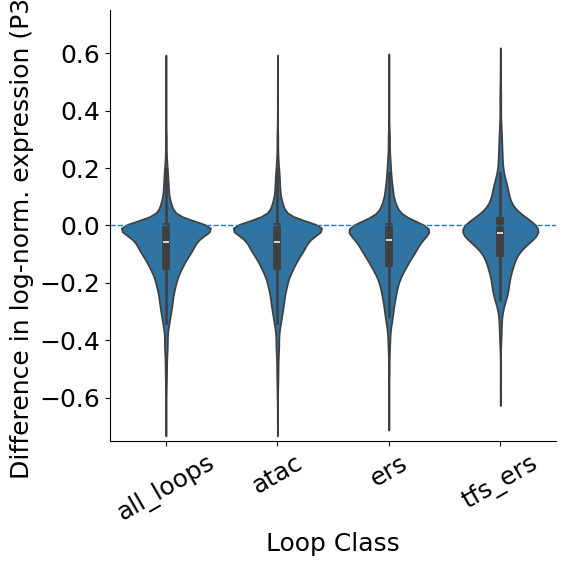


Pairwise Mann-Whitney U results (BH corrected):
      Group1   Group2       p_value         FDR_q
2  all_loops  tfs_ers  6.852447e-21  2.055734e-20
4       atac  tfs_ers  6.205075e-21  2.055734e-20
5        ers  tfs_ers  8.239463e-14  1.647893e-13
1  all_loops      ers  2.985961e-03  3.583153e-03
3       atac      ers  2.492666e-03  3.583153e-03
0  all_loops     atac  9.402681e-01  9.402681e-01
LoopClass
all_loops    6634
atac         6554
ers          3737
tfs_ers       761
dtype: int64


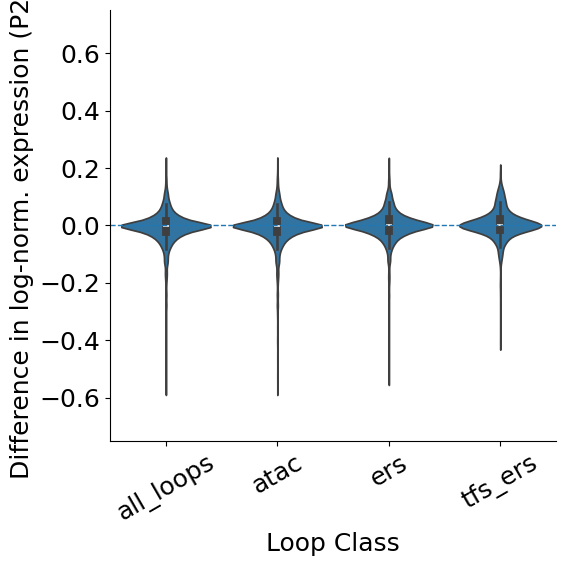


Pairwise Mann-Whitney U results (BH corrected):
      Group1   Group2       p_value         FDR_q
1  all_loops      ers  1.408461e-13  4.225384e-13
3       atac      ers  1.105871e-13  4.225384e-13
2  all_loops  tfs_ers  1.987932e-09  2.981898e-09
4       atac  tfs_ers  1.767722e-09  2.981898e-09
5        ers  tfs_ers  4.708459e-02  5.650150e-02
0  all_loops     atac  9.408925e-01  9.408925e-01
LoopClass
all_loops    6634
atac         6554
ers          3737
tfs_ers       761
dtype: int64


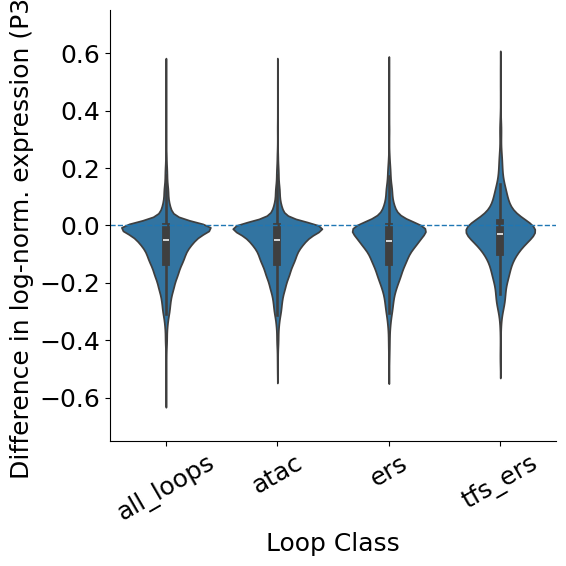


Pairwise Mann-Whitney U results (BH corrected):
      Group1   Group2       p_value         FDR_q
2  all_loops  tfs_ers  9.379358e-15  2.813808e-14
4       atac  tfs_ers  8.431015e-15  2.813808e-14
5        ers  tfs_ers  2.752908e-13  5.505815e-13
0  all_loops     atac  9.404266e-01  9.788811e-01
1  all_loops      ers  9.788811e-01  9.788811e-01
3       atac      ers  9.716766e-01  9.788811e-01


In [90]:

for sub in ['P31', 'P21', 'P32']:
    all_tpms = []
    grouped_values = {}
    for loopfile in loops_dict:

        loop_classes = read_loop_classes(loops_dict[loopfile])
        pls_path = os.path.join(
            basedir,
            f"{loops_dict[loopfile].split('.txt')[0]}_pls.txt"
        )

        # Restrict to CRE-only loop classes
        loops_sub = loop_classes[
            loop_classes['class'].isin(['E-E', 'E-P', 'P-P'])
        ]
        pls = pd.read_csv(pls_path, sep='\t')

        pls_sub = pls.merge(
            loops_sub,
            on=['chr1','start1','end1','chr2','start2','end2'],
            how='inner'
        )

        tpms_sub = tpm_df.merge(
            pls_sub,
            left_index=True,
            right_on='gene_name',
            how='inner'
        )


        # Compute log2 fold change
        tpms_sub['P31_log2fc'] = tpms_sub['P3'] - tpms_sub['P1']
        tpms_sub['P21_log2fc'] = tpms_sub['P2'] - tpms_sub['P1']
        tpms_sub['P32_log2fc'] = tpms_sub['P3'] - tpms_sub['P2']

        # Keep only needed columns
        tpms_sub = tpms_sub[[f'{sub}_log2fc']].copy()
        tpms_sub['LoopClass'] = loopfile   # label dataset

        all_tpms.append(tpms_sub)
        grouped_values[loopfile] = tpms_sub[[f'{sub}_log2fc']].values.flatten()


    plot_df = pd.concat(all_tpms, ignore_index=True)
    plot_df = plot_df.replace([np.inf, -np.inf], np.nan).dropna()
    plt.figure(figsize=(6,6))
    sns.violinplot(
        data=plot_df,
        x='LoopClass',
        y=f'{sub}_log2fc',
        inner='box'
    )
    print(plot_df.groupby('LoopClass').agg('size'))
    plt.axhline(0, linestyle='--', linewidth=1)
    plt.ylabel(f'Difference in log-norm. expression ({sub})')
    plt.xlabel('Loop Class')
    plt.xticks(rotation=30)
    plt.tight_layout()
    plt.ylim([-0.75, 0.75])
    #plt.savefig(os.path.join(savedir, f'loop_tpm_violin_multiome_{sub}.svg'))
    plt.show()
    #print(grouped_values)
    comparisons = list(itertools.combinations(grouped_values.keys(), 2))
    
    pvals = []
    for g1, g2 in comparisons:
        stat, p = mannwhitneyu(
            grouped_values[g1],
            grouped_values[g2],
            alternative='two-sided'
        )
        pvals.append(p)

    qvals = benjamini_hochberg(pvals)

    stats_df = pd.DataFrame({
        "Group1": [c[0] for c in comparisons],
        "Group2": [c[1] for c in comparisons],
        "p_value": pvals,
        "FDR_q": qvals
    })

    print("\nPairwise Mann-Whitney U results (BH corrected):")
    print(stats_df.sort_values("FDR_q"))
    
    

In [91]:
tpm_df = pd.read_csv('/mnt/md0/varshini/Analysis/Blood/GeneExp/tpm_avg_annotated.tsv', sep='\t')

In [92]:
lower_pct = 0.05
upper_pct = 0.95

tpm_df = tpm_df[
    tpm_df['P1'].between(tpm_df['P1'].quantile(lower_pct), tpm_df['P1'].quantile(upper_pct), inclusive='both') &
    tpm_df['P2'].between(tpm_df['P2'].quantile(lower_pct), tpm_df['P2'].quantile(upper_pct), inclusive='both') &
    tpm_df['P3'].between(tpm_df['P3'].quantile(lower_pct), tpm_df['P3'].quantile(upper_pct), inclusive='both')
]


MannwhitneyuResult(statistic=719920.0, pvalue=1.388250707981379e-39)


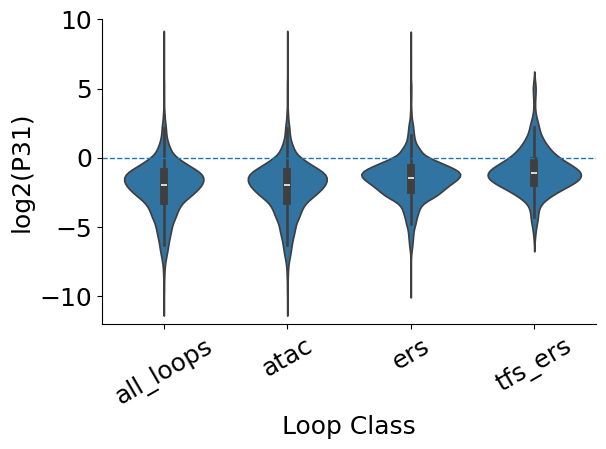

MannwhitneyuResult(statistic=899570.0, pvalue=3.6803452177240165e-14)


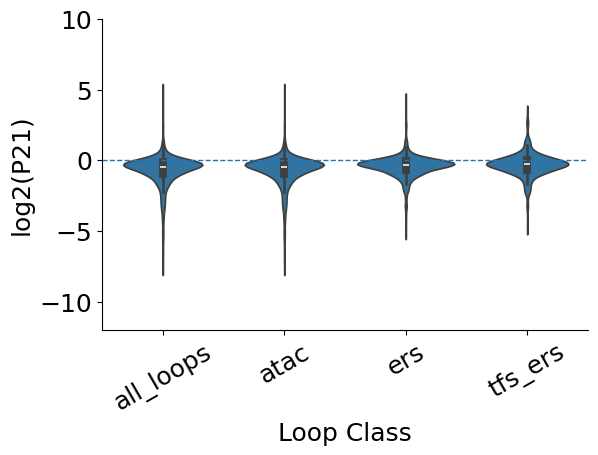

MannwhitneyuResult(statistic=756919.5, pvalue=2.4552022141317478e-33)


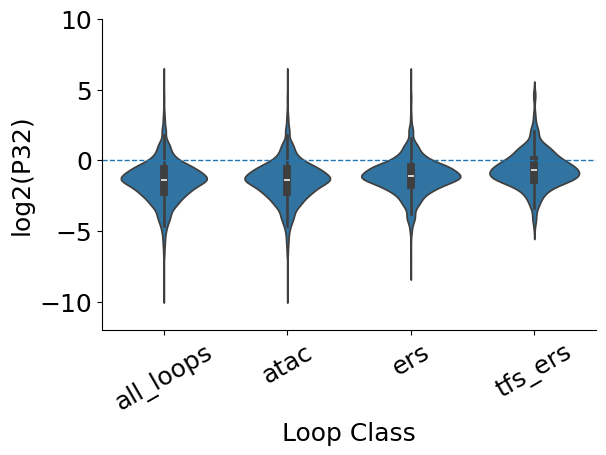

In [61]:

for sub in ['P31', 'P21', 'P32']:
    all_tpms = []
    for loopfile in loops_dict:

        loop_classes = read_loop_classes(loops_dict[loopfile])
        pls_path = os.path.join(
            basedir,
            f"{loops_dict[loopfile].split('.txt')[0]}_pls.txt"
        )

        # Restrict to CRE-only loop classes
        loops_sub = loop_classes[
            loop_classes['class'].isin(['E-E', 'E-P', 'P-P'])
        ]
        pls = pd.read_csv(pls_path, sep='\t')

        pls_sub = pls.merge(
            loops_sub,
            on=['chr1','start1','end1','chr2','start2','end2'],
            how='inner'
        )

        tpms_sub = tpm_df.merge(
        pls_sub,
        left_on='ensembl_id',
        right_on='ensembl_gene_id',
        how='inner'
    )
    
        # Compute log2 fold change
        tpms_sub['P31_log2fc'] = np.log2(tpms_sub['P3'] / tpms_sub['P1'])
        tpms_sub['P21_log2fc'] = np.log2(tpms_sub['P2'] / tpms_sub['P1'])
        tpms_sub['P32_log2fc'] = np.log2(tpms_sub['P3'] / tpms_sub['P2'])

        # Keep only needed columns
        tpms_sub = tpms_sub[[f'{sub}_log2fc']].copy()
        tpms_sub['LoopClass'] = loopfile   # label dataset

        all_tpms.append(tpms_sub)


    plot_df = pd.concat(all_tpms, ignore_index=True)
    plot_df = plot_df.replace([np.inf, -np.inf], np.nan).dropna()

    sns.violinplot(
        data=plot_df,
        x='LoopClass',
        y=f'{sub}_log2fc',
        inner='box'
    )
    print(mannwhitneyu(2**plot_df[plot_df['LoopClass']=='all_loops'][f'{sub}_log2fc'],2**plot_df[plot_df['LoopClass']=='tfs_ers'][f'{sub}_log2fc'] ))
    plt.axhline(0, linestyle='--', linewidth=1)
    plt.ylabel(f'log2({sub})')
    plt.xlabel('Loop Class')
    plt.xticks(rotation=30)
    plt.tight_layout()
    plt.ylim([-12, 10])
    #plt.savefig(os.path.join(savedir, f'loop_tpm_violin_cellrep_{sub}.svg'))
    plt.show()

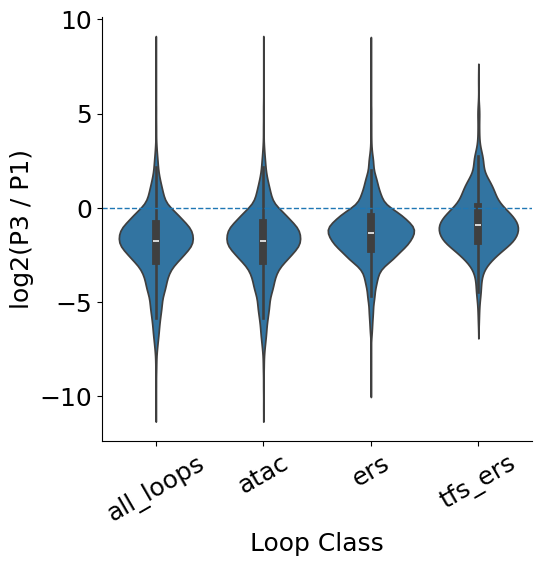

ValueError: Could not interpret value `P21_log2fc` for `y`. An entry with this name does not appear in `data`.

In [29]:
all_tpms = []

for loopfile in loops_dict:

    loop_classes = read_loop_classes(loops_dict[loopfile])
    pls_path = os.path.join(
        basedir,
        f"{loops_dict[loopfile].split('.txt')[0]}_pls.txt"
    )

    # Restrict to CRE-only loop classes
    loops_sub = loop_classes[
        loop_classes['class'].isin(['E-E', 'E-P', 'P-P'])
    ]
    pls = pd.read_csv(pls_path, sep='\t')

    pls_sub = pls.merge(
        loops_sub,
        on=['chr1','start1','end1','chr2','start2','end2'],
        how='inner'
    )

    tpms_sub = tpm_df.merge(
        pls_sub,
        left_on='ensembl_id',
        right_on='ensembl_gene_id',
        how='inner'
    )
    

    # Compute log2 fold change
    tpms_sub['P31_log2fc'] = np.log2(tpms_sub['P3'] / tpms_sub['P1'])
    tpms_sub['P21_log2fc'] = np.log2(tpms_sub['P2'] / tpms_sub['P1'])
    tpms_sub['P32_log2fc'] = np.log2(tpms_sub['P3'] / tpms_sub['P2'])
    
    # Keep only needed columns
    tpms_sub = tpms_sub[['P31_log2fc']].copy()
    tpms_sub['LoopClass'] = loopfile   # label dataset

    all_tpms.append(tpms_sub)


plot_df = pd.concat(all_tpms, ignore_index=True)
plot_df = plot_df.replace([np.inf, -np.inf], np.nan).dropna()
plt.figure(figsize=(6,6))



for sub in ['P31', 'P21', 'P32']:
    sns.violinplot(
        data=plot_df,
        x='LoopClass',
        y=f'{sub}_log2fc',
        inner='box'
    )

    plt.axhline(0, linestyle='--', linewidth=1)
    plt.ylabel('log2(P3 / P1)')
    plt.xlabel('Loop Class')
    plt.xticks(rotation=30)
    plt.tight_layout()
    #plt.savefig(os.path.join(savedir, f'loop_tpm_violin_cellrep_{sub}.svg'))
    plt.show()